# 2110446 DATA SCIENCE AND DATA ENGINEERING

## **Midterm:** Traffy Fondue

- **Author:** Worralop Srichainont
- **Year:** 2025 (Semester 2)

## **Notebook III:** Deep Learning Model

In this notebook, we are focus on building Deep Learning model by using `PhayaThaiBERT` for text classification.

# **Part 0:** Dependencies

In [1]:
!pip install -U datasets \
                transformers[sentencepiece] \
                lightning \
                scikit-learn \
                torchmetrics \
                iterative-stratification

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.

In [2]:
import torch
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib as mpl
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import MultilabelF1Score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar
from sklearn.metrics import f1_score, classification_report, multilabel_confusion_matrix

Setup Thai font for `matplotlib`

In [3]:
FONT_NAME = "Sarabun"
FONT_FILENAME = "Sarabun.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"

In [4]:
urllib.request.urlretrieve(FONT_URL, FONT_FILENAME)
mpl.font_manager.fontManager.addfont(FONT_FILENAME)
mpl.rc("font", family=FONT_NAME)

# **Part 1:** Load Dataset

In [5]:
TRAIN_FILE_PATH = (
    "/kaggle/input/datasets/worralopsrichainont/2110446-dsde-midterm-dataset-cleaned/train_cleaned.csv"
)

TEST_FILE_PATH = (
    "/kaggle/input/datasets/worralopsrichainont/2110446-dsde-midterm-dataset-cleaned/test_cleaned.csv"
)

In [6]:
df_train_all = pd.read_csv(TRAIN_FILE_PATH)
df_test = pd.read_csv(TEST_FILE_PATH)

Get brief details of the dataset

In [7]:
print(
    f"All train dataset has {df_train_all.shape[0]} rows and {df_train_all.shape[1]} columns"
)
for col_name in df_train_all.columns:
    print(f"- {col_name}")


All train dataset has 304284 rows and 14 columns
- id
- comment
- สำนักงานตำรวจแห่งชาติ
- การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย
- สภาเด็กและเยาวชนกรุงเทพมหานคร
- กรมควบคุมมลพิษ
- กรมสรรพสามิต
- การไฟฟ้านครหลวง
- กรมทางหลวง
- สำนักงานประกันสุขภาพแห่งชาติ
- การประปานครหลวง
- คณะกรรมการการพัฒนาเศรษฐกิจ
- กระทรวงการท่องเที่ยวและกีฬา
- สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200


In [8]:
print(f"The test dataset has {df_test.shape[0]} rows and {df_test.shape[1]} columns")
for col_name in df_test.columns:
    print(f"- {col_name}")

The test dataset has 37406 rows and 2 columns
- id
- comment


Display `DataFrame`

In [9]:
df_train_all.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
df_test.head()

,id,comment
0,0,รถติดจังเลยครับ อยากได้เกาะกลาง ที่ขยับเพิ่มเล...
1,1,ในซอยมีการเตรียมทำท่อระบายน้ำ โดยผู้รับเหมา มา...
2,2,มีต้นไม้กีดขวางทางสัญจรไปมาทำให้เกิดอันตราย
3,3,ร้านนวดบริเวณนี้วางของเกะกะบนทางเท้ามากมาย
4,4,ศูนย์เรื่องราวร้องทุกข์ ได้รับการประสานผ่านระบ...


# **Part 2:** Data Spliting

## 2.1. Multi-Label Stratification

In [11]:
VALIDATION_DATASET_RATIO = 0.1
SEED = 42

TEXT_COL = "comment"

LABEL_COLS = [
    "สำนักงานตำรวจแห่งชาติ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร",
    "กรมควบคุมมลพิษ",
    "กรมสรรพสามิต",
    "การไฟฟ้านครหลวง",
    "กรมทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ",
    "การประปานครหลวง",
    "คณะกรรมการการพัฒนาเศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200",
]

In [12]:
# Extract feature and label
X = df_train_all['comment'].to_numpy()
y = df_train_all[LABEL_COLS].to_numpy()

In [13]:
# Create a multi-label dataset splitter
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VALIDATION_DATASET_RATIO,
    random_state=SEED
)

In [14]:
# Begin dataset splitting
for train_index, val_index in msss.split(X, y):
    df_train = df_train_all.iloc[train_index].reset_index(drop=True)
    df_val = df_train_all.iloc[val_index].reset_index(drop=True)

## 2.2. Display Dataset

In [15]:
print(f"The train dataset has {df_train.shape[0]} rows and {df_train.shape[1]} columns")

The train dataset has 273855 rows and 14 columns


In [16]:
df_train.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
print(
    f"The validation dataset has {df_val.shape[0]} rows and {df_val.shape[1]} columns"
)

The validation dataset has 30429 rows and 14 columns


In [18]:
df_val.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,13,เรื่องจุดพลุ บริเวณบ้านคน โดยไม่ได้รับอนุญาต ข...,0,0,0,0,0,0,0,0,0,0,0,0
1,45,พิกัด คือ บนสะพานข้ามแยกรามอินทรา (มุ่งหน้าไปท...,0,0,0,0,0,0,1,0,0,0,0,0
2,47,ปัญหา: เบสท์ บนสะพานอนุทินสวัสดิ์ (กลางสะพาน ฝ...,0,0,0,0,0,0,0,0,0,0,0,0
3,50,ปัญหา: ปากซอย 5 ของชุมชนดังกล่าว พบมีการมั่วสุ...,1,0,0,0,0,0,0,0,0,0,0,0
4,59,ปัญหา: พบบ้าน(ไม่ทราบเลขที่) มีการเปิดเพลงส่งเ...,0,0,0,0,0,0,0,0,0,0,0,0


# **Part 3:** Data Pipeline

## 3.1. PyTorch Lightning Seed

In [19]:
pl.seed_everything(42, workers=True)

Seed set to 42


42

## 3.2. Text Tokenizer

According to EDA, mean token of both datasets are only around 50-52 tokens and 95th percentile of both datasets are around 148-153 tokens. Thus, we should set `MAX_LENGTH` to `128`

In [20]:
MODEL_NAME = "clicknext/phayathaibert"
MAX_LENGTH = 128

TEXT_COL = "comment"

In [21]:
class ThaiTokenizer:
    # Load pre-trained PhayaThaiBERT tokenizer
    TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

    @staticmethod
    def get_encoded_text(text):
        # Encode text by using the tokenizer
        encoded_text = ThaiTokenizer.TOKENIZER(
            str(text),
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            add_special_tokens=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        # Return an encoded text
        return encoded_text

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.26M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.4M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

## 3.3. PyTorch Dataset Class

In [22]:
TEXT_COL = "comment"

LABEL_COLS = [
    "สำนักงานตำรวจแห่งชาติ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร",
    "กรมควบคุมมลพิษ",
    "กรมสรรพสามิต",
    "การไฟฟ้านครหลวง",
    "กรมทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ",
    "การประปานครหลวง",
    "คณะกรรมการการพัฒนาเศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200",
]

In [23]:
class TraffyFondueDataset(Dataset):
    def __init__(self, df, has_label):
        # Store if the the dataset has label or not
        self.has_label = has_label

        # Separate text and label from a Pandas DataFrame
        self.texts = df[TEXT_COL].to_numpy()
        if self.has_label:
            self.labels = df[LABEL_COLS].to_numpy(dtype=np.float32)

        # Store rows amount of the dataset
        self.n_rows = df.shape[0]

    def __len__(self):
        # Return length of the dataset
        return self.n_rows

    def __getitem__(self, idx):
        # Encode the text using tokenizer
        encoded_text = ThaiTokenizer.get_encoded_text(self.texts[idx])

        # Return an item as a dict
        item = {
            "input_ids": encoded_text["input_ids"].squeeze(0),
            "attention_mask": encoded_text["attention_mask"].squeeze(0),
        }
        if self.has_label:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

## 3.4. PyTorch DataLoader

In [24]:
BATCH_SIZE = 32
NUM_WORKERS = 2

In [25]:
class TraffyFondueDataModule(pl.LightningDataModule):
    def __init__(self, df_train, df_val, df_test):
        super().__init__()
        self.batch_size = BATCH_SIZE
        self.num_workers = NUM_WORKERS

        self.df_train = df_train
        self.df_val = df_val
        self.df_test = df_test

    def train_dataloader(self):
        dataset_train = TraffyFondueDataset(self.df_train, True)

        return DataLoader(
            dataset_train,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        dataset_val = TraffyFondueDataset(self.df_val, True)

        return DataLoader(
            dataset_val,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def test_dataloader(self):
        dataset_test = TraffyFondueDataset(self.df_test, False)

        return DataLoader(
            dataset_test,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

# **Part 4:** PhayaThaiBERT Model

## 4.1. Configuration

In [26]:
MODEL_NAME = "clicknext/phayathaibert"

LABEL_COLS = [
    "สำนักงานตำรวจแห่งชาติ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร",
    "กรมควบคุมมลพิษ",
    "กรมสรรพสามิต",
    "การไฟฟ้านครหลวง",
    "กรมทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ",
    "การประปานครหลวง",
    "คณะกรรมการการพัฒนาเศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200",
]

## 4.2. Positive Weights

By adjusting `pos_weight` can handle class imbalance.

$${\text{pos\_weight}}_{\text{class}} = \frac{\text{Number of Negative Samples}}{\text{Number of Positive Samples}}$$

In [27]:
class PositiveWeightCalculator:
    @staticmethod
    def get_pos_weight(df, max_pos_weight=20.0):
        # Get total rows of the DataFrame
        total_counts = df.shape[0]

        # Count positives in each class
        pos_counts = df[LABEL_COLS].sum(axis=0).values

        # Calculate positive weight
        pos_weight = (total_counts - pos_counts) / (pos_counts + 1e-5)
        pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

        # Clamp the weights wtihin the range
        pos_weight = torch.clamp(pos_weight, max=max_pos_weight)

        # Return positive weight
        return pos_weight

## 4.3. Model

In [28]:
class TraffyFondueClassifier(pl.LightningModule):
    def __init__(self, pos_weight, n_classes=12, learning_rate=5e-5):
        super().__init__()

        # Download pre-trained PhayaThaiBERT model
        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=n_classes
        )

        # Loss function
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        # Evaluation Metric
        self.macro_f1 = MultilabelF1Score(num_labels=n_classes, average="macro")

        # Ignore pos_weight on model logging
        self.save_hyperparameters(ignore=["pos_weights"])

    def forward(self, input_ids, attention_mask):
        # Pass tokenized text and attention through Transformer layers
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)

        # Return logits score
        return outputs.logits

    def training_step(self, batch, batch_idx):
        # Get information from a data batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Calculate logits score and loss
        logits = self(input_ids, attention_mask)
        loss = self.loss_fn(logits, labels)

        # Log training results
        self.log(
            "train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        # Get information from a data batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        # Calculate logits score and loss
        logits = self(input_ids, attention_mask)
        loss = self.loss_fn(logits, labels)

        # Calculate the macro F1 score
        f1 = self.macro_f1(logits, labels)

        # Log validation results
        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_macro_f1", f1, on_epoch=True, prog_bar=True, logger=True)

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        # Get information from a data batch
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        # Calculate logits score
        logits = self(input_ids, attention_mask)
        return logits

    def configure_optimizers(self):
        # Use Adam with weight decay as optimizer
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.learning_rate, weight_decay=0.01
        )
        return optimizer

# **Part 5:** Model Training

## 5.1. Create DataModule

In [29]:
# Create PyTorch DataModule from a DataFrame
data_module = TraffyFondueDataModule(df_train, df_val, df_test)

## 5.2. Create a Model

In [30]:
# Calculate pos_weight for a model
pos_weight = PositiveWeightCalculator.get_pos_weight(df_train)

In [31]:
# Create a model
model = TraffyFondueClassifier(pos_weight)

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: clicknext/phayathaibert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 5.3. Create a Trainer

In [32]:
OUTPUT_PATH = "/kaggle/working/best_model/"
MODEL_FILENAME = "model-best-f1"

In [33]:
# Create a early stopping mechanism
early_stop = EarlyStopping(monitor="val_macro_f1", mode="max", patience=2)

In [34]:
# Create a model checkpoint which saves the best model
checkpoint = ModelCheckpoint(
    monitor="val_macro_f1",
    mode="max",
    dirpath=OUTPUT_PATH,
    filename=MODEL_FILENAME,
    save_top_k=1,
)

In [35]:
# Create a progress bar for every 50 batches to prevent Kaggle to crash
progress_bar = TQDMProgressBar(refresh_rate=50)

In [36]:
# Create a trainer to train a model
trainer = pl.Trainer(
    accelerator="auto",
    devices="auto",
    precision="16-mixed",
    max_epochs=4,
    log_every_n_steps=10,
    val_check_interval=0.25,
    callbacks=[early_stop, checkpoint, progress_bar],
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## 5.4. Train a Model

In [37]:
trainer.fit(model=model, datamodule=data_module)

2026-02-24 08:47:20.439912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771922840.621997      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771922840.677248      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771922841.135323      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771922841.135374      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771922841.135377      24 computation_placer.cc:177] computation placer alr

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ CamembertForSequenceClassification │  277 M │ eval  │     0 │
│ 1 │ loss_fn  │ BCEWithLogitsLoss                  │      0 │ train │     0 │
│ 2 │ macro_f1 │ MultilabelF1Score                  │      0 │ train │     0 │
└───┴──────────┴────────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 277 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 277 M                                                                                                
Total estimated model params size (MB): 1.1 K                                                                      
Modules in train mode: 2                                                                                           
Modules in eval mode: 230                                                                                          
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 230 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

# **Part 6:** Validation Results

## 6.1. Configuration

In [38]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

LABEL_COLS = list(CATEGORY_MAP.keys())
SHORT_LABEL_COLS = list(CATEGORY_MAP.values())

## 6.2. Validation Dataset Prediction

In [39]:
class LogitsConverter:
    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.thresholds = np.full(self.n_classes, 0.5)

    def tuning_all_thresholds(self, predictions, y_true):
        # Convert logits score to probability
        logits = torch.cat(predictions, dim=0)
        probs = torch.sigmoid(logits).numpy()

        # Iterate each class and calculate the best threshold
        for idx in range(self.n_classes):
            self.tuning_class_thresholds(probs[:, idx], y_true[:, idx], idx)

    def tuning_class_thresholds(self, probs_class, y_true_class, idx):
        best_thresh = 0.5
        best_f1 = 0.0

        # Iterate each threshold and find the best one
        for thresh in np.arange(0.05, 0.95, 0.01):
            # Predict by using the current threshold
            y_pred_class = (probs_class > thresh).astype(int)

            # Calculate F1 score from a prediction
            f1 = f1_score(y_true_class, y_pred_class, zero_division=0)

            # Save the best threshold for the class
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        # Update to class attributes
        self.thresholds[idx] = best_thresh

    def get_all_binary(self, predictions):
        # Convert logits score to probability
        logits = torch.cat(predictions, dim=0)
        probs = torch.sigmoid(logits).numpy()

        # Create an empty predictions array
        n_rows = probs.shape[0]
        y_pred = np.zeros((n_rows, self.n_classes), dtype=int)

        # Iterate each class and get its predictions
        for idx in range(self.n_classes):
            y_pred[:, idx] = self.get_class_binary(probs[:, idx], idx)

        # Return all prediction
        return y_pred

    def get_class_binary(self, probs_class, idx):
        # Predict by using the tuned threshold
        y_pred_class = (probs_class > self.thresholds[idx]).astype(int)

        # Return class prediction
        return y_pred_class

In [40]:
# Predict validation dataset
val_predictions = trainer.predict(
    model, dataloaders=data_module.val_dataloader(), ckpt_path="best"
)

Restoring states from the checkpoint path at /kaggle/working/best_model/model-best-f1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at /kaggle/working/best_model/model-best-f1.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

In [41]:
# Load ground truth labels
y_true = df_val[LABEL_COLS].values

In [42]:
# Tuning prediction thresholds
logits_converter = LogitsConverter(len(LABEL_COLS))
logits_converter.tuning_all_thresholds(val_predictions, y_true)

# Get predictions as an array of 0 and 1
y_pred = logits_converter.get_all_binary(val_predictions)

## 6.3. Confusion Matrix

In [43]:
class MultiLabelCofusionMatrixPlot:
    @staticmethod
    def get_plot(y_true, y_pred):
        # Get confusion matrix for each class
        mcm = multilabel_confusion_matrix(y_true, y_pred)

        # Create a grid of subplots
        fig, axes = plt.subplots(3, 4, figsize=(25, 20))
        axes = axes.ravel()

        # Plot each matrix in each grid
        for i, (matrix, organization_name) in enumerate(zip(mcm, LABEL_COLS)):
            sns.heatmap(
                matrix,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                ax=axes[i],
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"],
            )
            axes[i].set_title(organization_name)

        # Display a confusion matrix
        plt.tight_layout()
        plt.show()

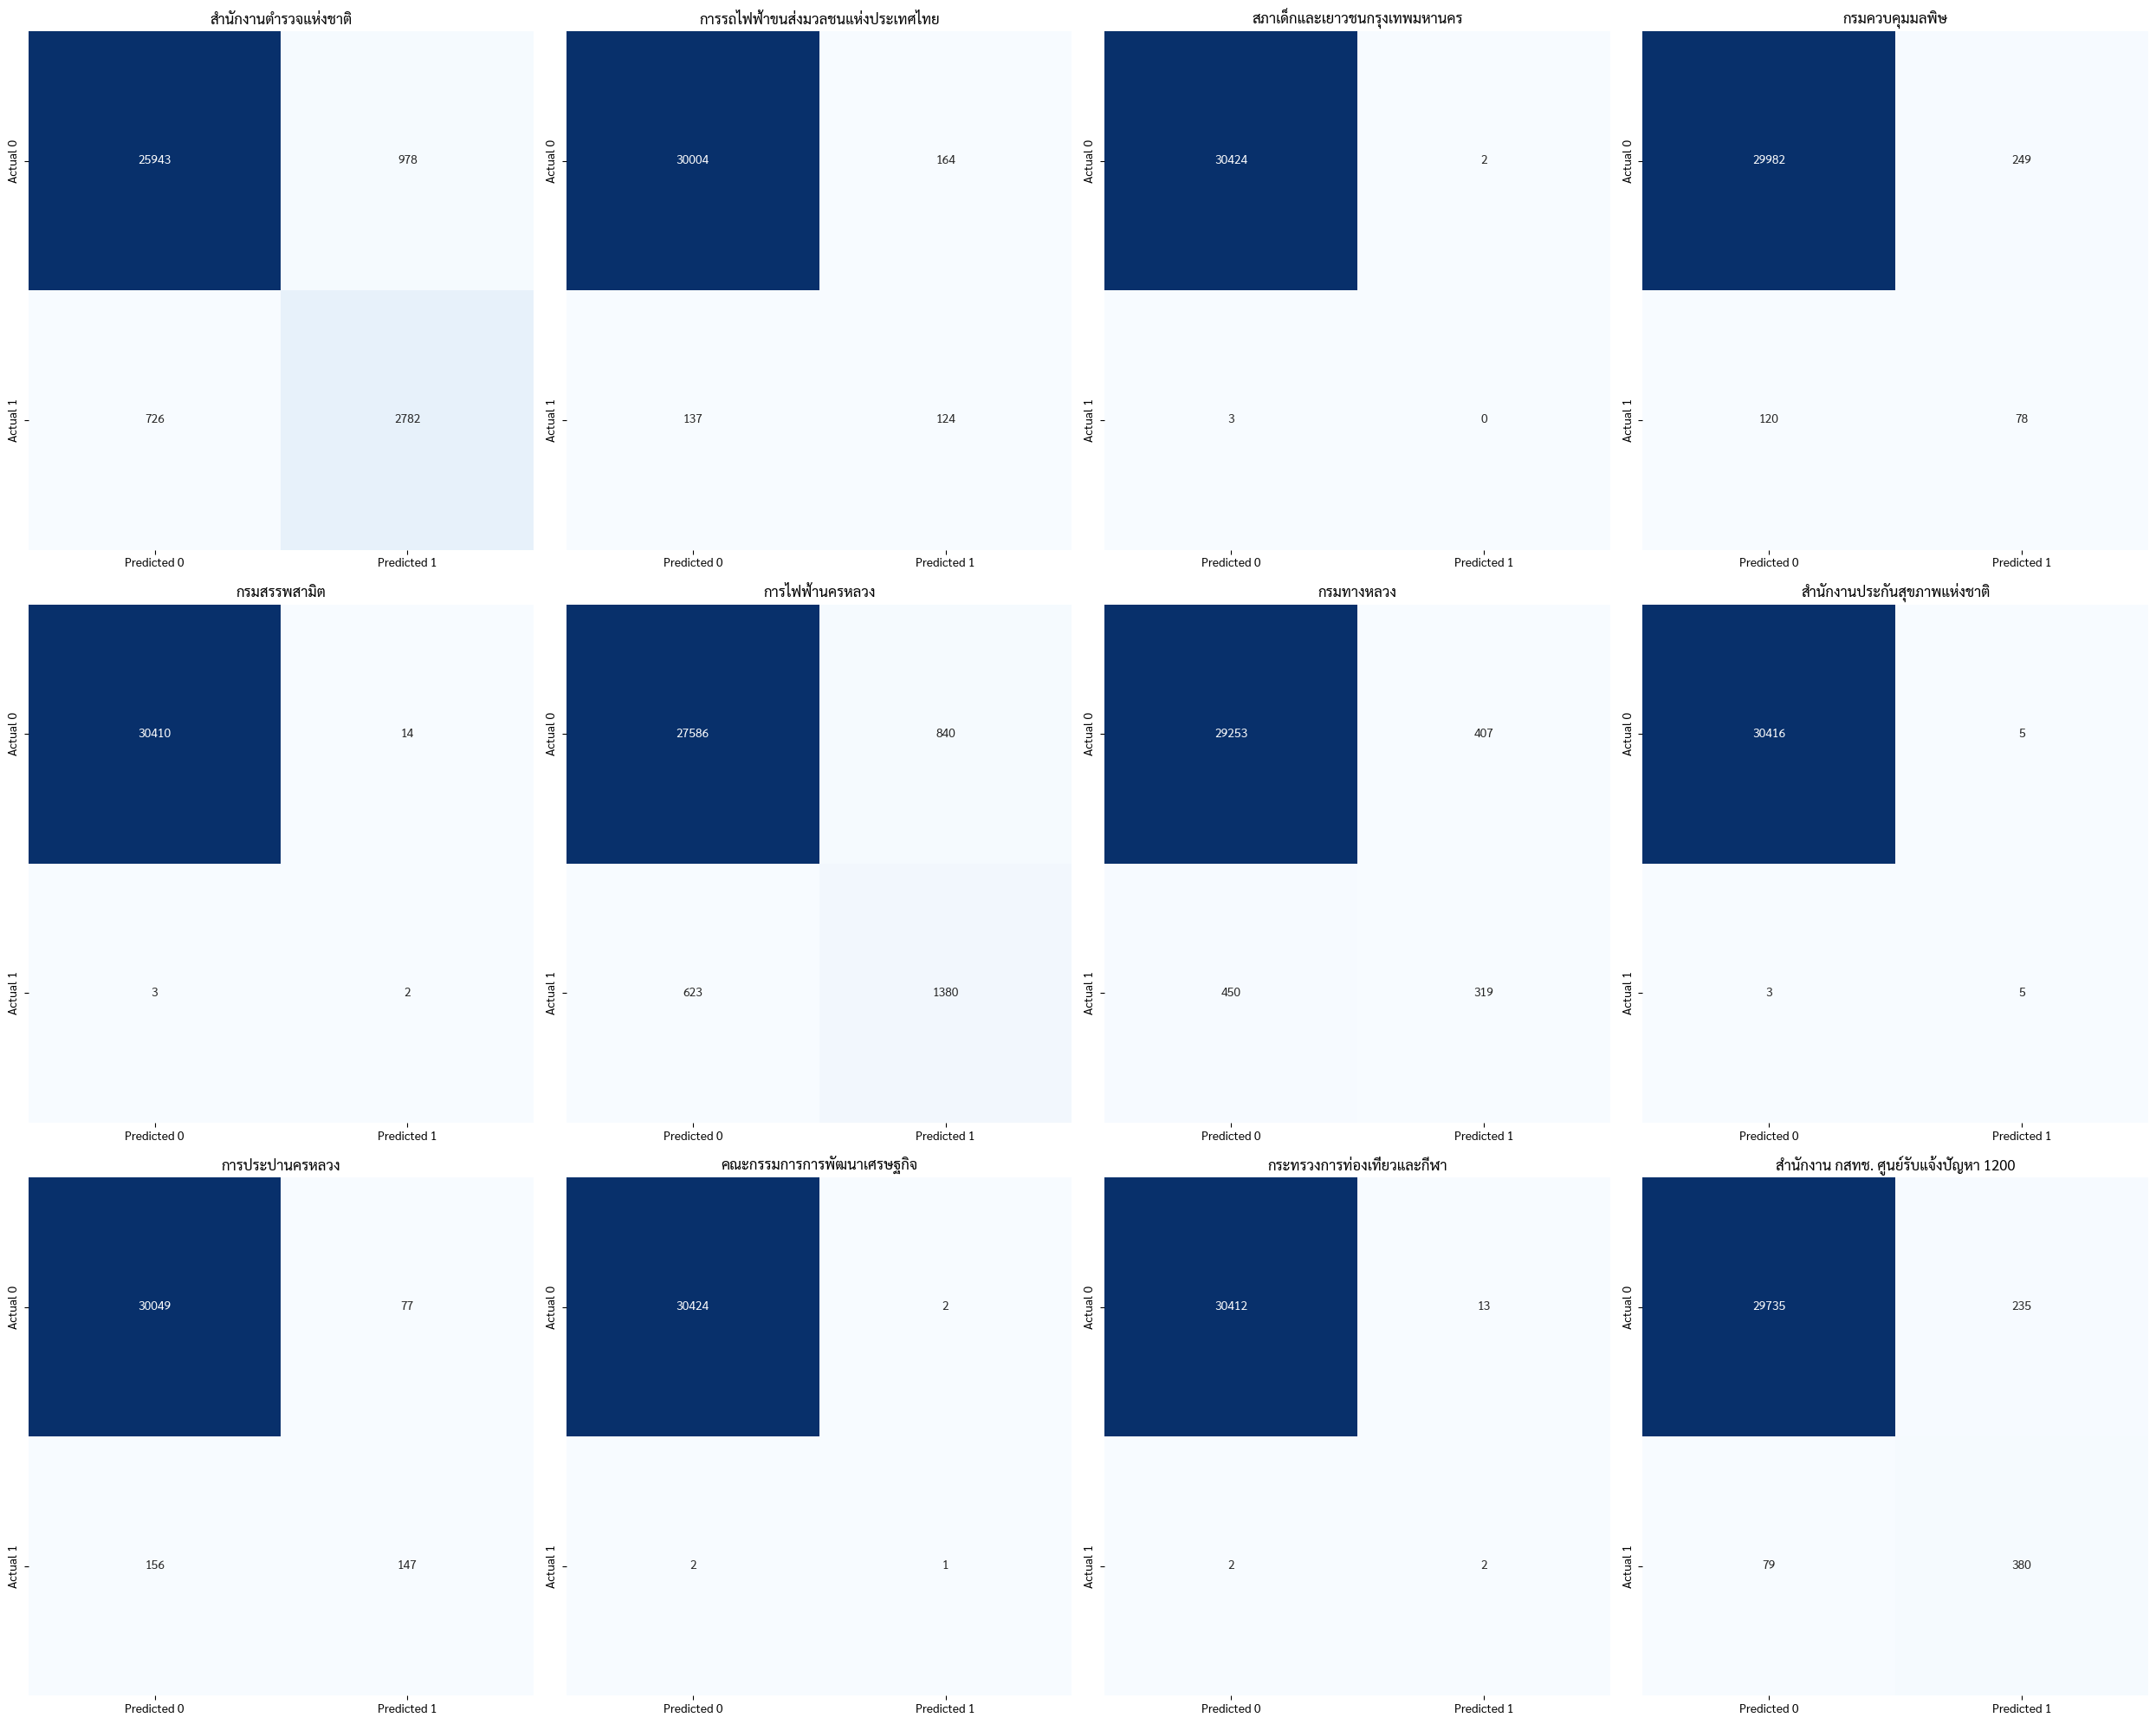

In [44]:
MultiLabelCofusionMatrixPlot.get_plot(y_true, y_pred)

## 6.4. Classification Report

In [45]:
print(f"{"=" * 20} CLASSIFICATION REPORT {"=" * 20}")
print(
    classification_report(
        y_true, y_pred, target_names=SHORT_LABEL_COLS, zero_division=0
    )
)

==================== CLASSIFICATION REPORT ====================
                   precision    recall  f1-score   support

            ตำรวจ       0.74      0.79      0.77      3508
          รถไฟฟ้า       0.43      0.48      0.45       261
          สภาเด็ก       0.00      0.00      0.00         3
            มลพิษ       0.24      0.39      0.30       198
        สรรพสามิต       0.12      0.40      0.19         5
            ไฟฟ้า       0.62      0.69      0.65      2003
          ทางหลวง       0.44      0.41      0.43       769
     ประกันสุขภาพ       0.50      0.62      0.56         8
            ประปา       0.66      0.49      0.56       303
         เศรษฐกิจ       0.33      0.33      0.33         3
ท่องเที่ยวและกีฬา       0.13      0.50      0.21         4
             กสทช       0.62      0.83      0.71       459

        micro avg       0.64      0.69      0.66      7524
        macro avg       0.40      0.49      0.43      7524
     weighted avg       0.64      0.69      0.66 

# **Part 7:** Submission

## 7.1. Predictions

In [46]:
# Predict test dataset
predictions = trainer.predict(
    model, dataloaders=data_module.test_dataloader(), ckpt_path="best"
)

# Convert to an array of 0 and 1
y_pred = logits_converter.get_all_binary(predictions)

Restoring states from the checkpoint path at /kaggle/working/best_model/model-best-f1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at /kaggle/working/best_model/model-best-f1.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

## 7.2. Create a CSV Submission

In [47]:
LABEL_COLS = [
    "สำนักงานตำรวจแห่งชาติ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร",
    "กรมควบคุมมลพิษ",
    "กรมสรรพสามิต",
    "การไฟฟ้านครหลวง",
    "กรมทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ",
    "การประปานครหลวง",
    "คณะกรรมการการพัฒนาเศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200",
]

OUTPUT_PATH = "/kaggle/working/submission.csv"

In [48]:
# Create a DataFrame for submission
submission_df = pd.DataFrame({
    "id": df_test["id"]
})
submission_df[LABEL_COLS] = y_pred

In [49]:
# Save as CSV
submission_df.to_csv(OUTPUT_PATH, index=False)